In [1]:
import os

In [2]:
import pandas as pd

In [3]:
import numpy as np

In [4]:
df = pd.read_csv("./insurance.csv")

In [5]:
df.head(8)


,age,sex,bmi,children,smoker,region,charges
0,19.0,female,27.900,0.0,yes,southwest,16884.924
1,18.0,male,33.770,1.0,no,Southeast,1725.5523
2,28.0,male,33.000,3.0,no,southeast,$4449.462
3,33.0,male,22.705,0.0,no,northwest,$21984.47061
4,32.0,male,28.880,0.0,no,northwest,$3866.8552
5,-31.0,woman,25.740,0.0,no,southeast,$3756.6216
6,46.0,woman,33.440,1.0,no,southeast,8240.5896
7,37.0,female,27.740,3.0,no,Northwest,7281.5056


# TASK 1: CLEAN UP THE DATA
are there any missing values?
standarize categories
standardize sex to two categories
standarize charges data type

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1272 non-null   float64
 1   sex       1272 non-null   object 
 2   bmi       1272 non-null   float64
 3   children  1272 non-null   float64
 4   smoker    1272 non-null   object 
 5   region    1272 non-null   object 
 6   charges   1284 non-null   object 
dtypes: float64(3), object(4)
memory usage: 73.3+ KB


In [7]:
insurance_filled = df.dropna()

In [8]:
insurance_filled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1208 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1208 non-null   float64
 1   sex       1208 non-null   object 
 2   bmi       1208 non-null   float64
 3   children  1208 non-null   float64
 4   smoker    1208 non-null   object 
 5   region    1208 non-null   object 
 6   charges   1208 non-null   object 
dtypes: float64(3), object(4)
memory usage: 75.5+ KB


In [9]:
insurance_filled['region'].unique()

array(['southwest', 'Southeast', 'southeast', 'northwest', 'Northwest',
       'Northeast', 'northeast', 'Southwest'], dtype=object)

In [10]:
insurance_filled['region'] = insurance_filled['region'].str.lower()

C:\Users\newta\AppData\Local\Temp\ipykernel_6500\3864196100.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  insurance_filled['region'] = insurance_filled['region'].str.lower()


In [11]:
insurance_filled['sex'].unique()

array(['female', 'male', 'woman', 'F', 'man', 'M'], dtype=object)

In [12]:
FEMALE = "female"
MALE = "male"

sex_map = {'female': FEMALE, 'woman': FEMALE, 'male': MALE, 'F': FEMALE, 'man': MALE, 'M': MALE}

In [13]:
insurance_filled['sex'] = insurance_filled['sex'].replace(sex_map)

C:\Users\newta\AppData\Local\Temp\ipykernel_6500\2100468076.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  insurance_filled['sex'] = insurance_filled['sex'].replace(sex_map)


In [14]:
insurance_filled['sex'].unique()

array(['female', 'male'], dtype=object)

In [15]:
insurance_filled['smoker'] = (insurance_filled['smoker']=='yes')

C:\Users\newta\AppData\Local\Temp\ipykernel_6500\3701203390.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  insurance_filled['smoker'] = (insurance_filled['smoker']=='yes')


In [16]:
insurance_filled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1208 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1208 non-null   float64
 1   sex       1208 non-null   object 
 2   bmi       1208 non-null   float64
 3   children  1208 non-null   float64
 4   smoker    1208 non-null   bool   
 5   region    1208 non-null   object 
 6   charges   1208 non-null   object 
dtypes: bool(1), float64(3), object(3)
memory usage: 67.2+ KB


In [17]:
insurance_filled['charges'].sample(10)

519      3857.75925
532       12925.886
503      32548.3405
230      7443.64305
485      4347.02335
857      15817.9857
521       3994.1778
142       18972.495
1168        4670.64
323     11566.30055
Name: charges, dtype: object

In [18]:
insurance_filled['charges'] = insurance_filled['charges'].str.strip('$').astype('float64')

C:\Users\newta\AppData\Local\Temp\ipykernel_6500\1246388216.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  insurance_filled['charges'] = insurance_filled['charges'].str.strip('$').astype('float64')


In [19]:
insurance_filled['charges']

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1208, dtype: float64

In [20]:
df = insurance_filled.apply(lambda x: x.abs() if np.issubdtype(x.dtype, np.number) else x)

In [21]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19.0,female,27.900,0.0,True,southwest,16884.92400
1,18.0,male,33.770,1.0,False,southeast,1725.55230
2,28.0,male,33.000,3.0,False,southeast,4449.46200
3,33.0,male,22.705,0.0,False,northwest,21984.47061
4,32.0,male,28.880,0.0,False,northwest,3866.85520


In [22]:
df.to_csv('cleaned-data.csv', index=False)

# Task 2 : scatterplots of relationships between independent variables

In [23]:
import matplotlib.pyplot as plt

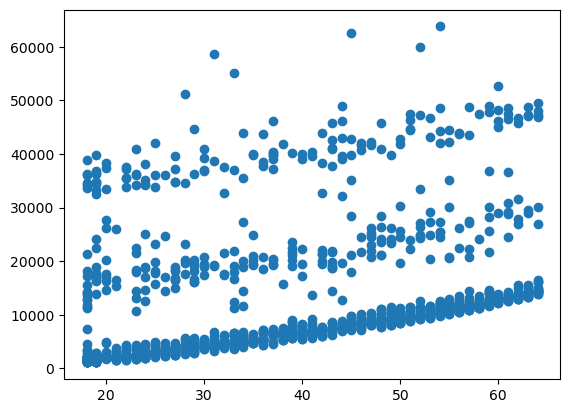

In [24]:
plt.scatter(df['age'], df['charges'])

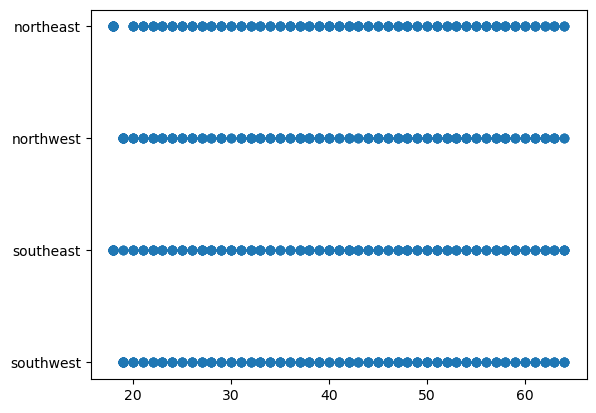

In [25]:
plt.scatter(df['age'], df['region'])

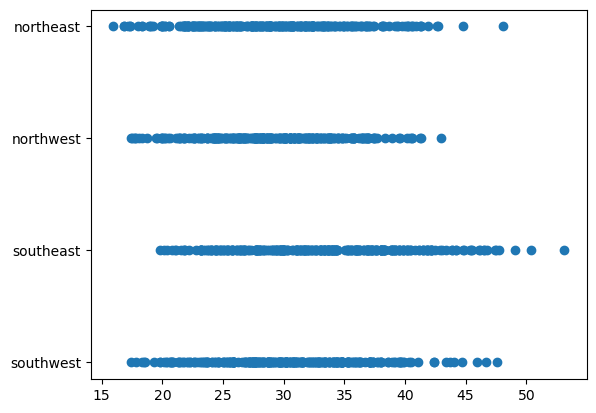

In [26]:
plt.scatter(df['bmi'], df['region'])

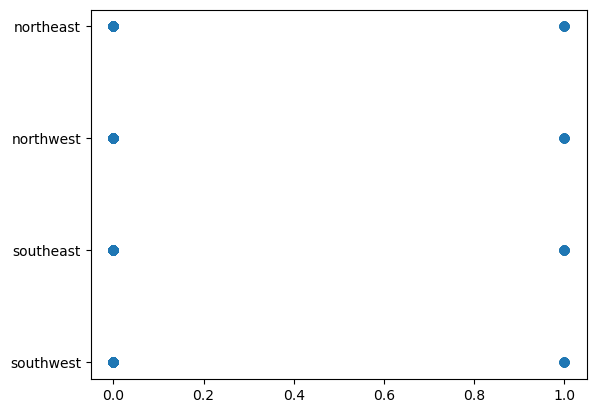

In [27]:
plt.scatter(df['smoker'], df['region'])

# Task 3 : Prepare data for a model fitting

In [28]:
df['is_southwest'] = (df['region'] == 'southwest')

In [29]:
df.head()

,age,sex,bmi,children,smoker,region,charges,is_southwest
0,19.0,female,27.900,0.0,True,southwest,16884.92400,True
1,18.0,male,33.770,1.0,False,southeast,1725.55230,False
2,28.0,male,33.000,3.0,False,southeast,4449.46200,False
3,33.0,male,22.705,0.0,False,northwest,21984.47061,False
4,32.0,male,28.880,0.0,False,northwest,3866.85520,False


In [30]:
df = pd.get_dummies(df, prefix = 'region', columns = ['region'])

In [31]:
df.head()

,age,sex,bmi,children,smoker,charges,is_southwest,region_northeast,region_northwest,region_southeast,region_southwest
0,19.0,female,27.900,0.0,True,16884.92400,True,False,False,False,True
1,18.0,male,33.770,1.0,False,1725.55230,False,False,False,True,False
2,28.0,male,33.000,3.0,False,4449.46200,False,False,False,True,False
3,33.0,male,22.705,0.0,False,21984.47061,False,False,True,False,False
4,32.0,male,28.880,0.0,False,3866.85520,False,False,True,False,False


In [32]:
df['region_northwest'].value_counts()

region_northwest
False    914
True     294
Name: count, dtype: int64

In [33]:
df  = df.drop(columns = ['region_northeast', 'region_northwest', 'region_southeast', 'region_southwest'])

In [34]:
df.head()

,age,sex,bmi,children,smoker,charges,is_southwest
0,19.0,female,27.900,0.0,True,16884.92400,True
1,18.0,male,33.770,1.0,False,1725.55230,False
2,28.0,male,33.000,3.0,False,4449.46200,False
3,33.0,male,22.705,0.0,False,21984.47061,False
4,32.0,male,28.880,0.0,False,3866.85520,False


In [35]:
df['smoker'] = df['smoker'].astype('int')

In [36]:
df.head()

,age,sex,bmi,children,smoker,charges,is_southwest
0,19.0,female,27.900,0.0,1,16884.92400,True
1,18.0,male,33.770,1.0,0,1725.55230,False
2,28.0,male,33.000,3.0,0,4449.46200,False
3,33.0,male,22.705,0.0,0,21984.47061,False
4,32.0,male,28.880,0.0,0,3866.85520,False


In [37]:
df['is_male'] = (df['sex'] == 'male').astype('int64')
    

In [38]:
df.head()

,age,sex,bmi,children,smoker,charges,is_southwest,is_male
0,19.0,female,27.900,0.0,1,16884.92400,True,0
1,18.0,male,33.770,1.0,0,1725.55230,False,1
2,28.0,male,33.000,3.0,0,4449.46200,False,1
3,33.0,male,22.705,0.0,0,21984.47061,False,1
4,32.0,male,28.880,0.0,0,3866.85520,False,1


In [39]:
df = df.drop(columns = ['sex'])

In [40]:
df.head()

,age,bmi,children,smoker,charges,is_southwest,is_male
0,19.0,27.900,0.0,1,16884.92400,True,0
1,18.0,33.770,1.0,0,1725.55230,False,1
2,28.0,33.000,3.0,0,4449.46200,False,1
3,33.0,22.705,0.0,0,21984.47061,False,1
4,32.0,28.880,0.0,0,3866.85520,False,1


# Task 4: Fit a linear regression model

In [41]:
df = df.dropna(subset=['charges'])

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
# from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import r2_score    

# Define input and output variables
X = df.drop(columns=['charges'])
y = df['charges']

print(df.info())
print(y.info())

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Create and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate the R squared score
r2_score = r2_score(y_test, y_pred)

# Output the mean squared error
r2_score

<class 'pandas.core.frame.DataFrame'>
Index: 1207 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           1207 non-null   float64
 1   bmi           1207 non-null   float64
 2   children      1207 non-null   float64
 3   smoker        1207 non-null   int64  
 4   charges       1207 non-null   float64
 5   is_southwest  1207 non-null   bool   
 6   is_male       1207 non-null   int64  
dtypes: bool(1), float64(4), int64(2)
memory usage: 67.2 KB
None
<class 'pandas.core.series.Series'>
Index: 1207 entries, 0 to 1337
Series name: charges
Non-Null Count  Dtype  
--------------  -----  
1207 non-null   float64
dtypes: float64(1)
memory usage: 18.9 KB
None


0.7271296104143804

# Task 5 : See How Model Perform on Validation set

### Helper function for pre processing

In [43]:
def preprocess_df(df):
    df_new = pd.get_dummies(df, prefix=['region'], columns=['region'])
    df_new = df_new.drop(columns=['region_southeast'])

    df_new['smoker'] = (df_new['smoker'] == 'yes')
    df_new['smoker'] = df_new['smoker'].astype('int64')

    df_new['is_male'] = (df_new['sex'] == 'male').astype('int64')
    df_new = df_new.drop(columns=['sex'])
    
    return df_new
    

In [44]:
# Implement model creation and training here
# Use as many cells as you need

# Task #5, see how model performs on validation dataset
# Subtask - Create helper function to preprocess dataframe

val_df = pd.read_csv('validation_dataset.csv')
input_df = preprocess_df(val_df)

predictions = model.predict(input_df)

validation_data = val_df.copy()

validation_data['predicted_charges'] = predictions

validation_data.loc[validation_data['predicted_charges'] < 1000, 'predicted_charges'] = 1000

validation_data.head()

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- region_northeast
- region_northwest
- region_southwest
Feature names seen at fit time, yet now missing:
- is_southwest
